# Lab 8 — Image Classification with Satellite Data

**Dataset:** EuroSAT (10 land-use classes, 27,000 satellite images)  
**Task:** Multi-class satellite image classification  
**Services:** Vision API, AutoML Vision, Vertex AI Custom Training, Experiments, Metadata  

---

## Lab Objectives

1. Build and evaluate a **tf.data pipeline** for image data (new skill)
2. Evaluate **Vision API** as a pre-trained baseline on domain-specific imagery
3. Train **AutoML Vision** as a managed transfer learning baseline
4. Build **custom transfer learning** models with MobileNetV2 (frozen → fine-tuned → augmented)
5. Log all runs to **Vertex AI Experiments** for structured comparison
6. Deploy the best model and build a **decision matrix** (Vision API vs AutoML vs Custom)
7. Track full **metadata lineage** from raw images to predictions

## Architecture Overview

```
EuroSAT (TFDS) → GCS bucket → [Vision API evaluation]
                             → [AutoML Vision training]
                             → [tf.data pipeline] → [Custom training (3 runs)] → [Endpoint]
                             → [Experiments comparison] → [Decision matrix]
```

## What's New in This Lab

| Concept | Previous Labs | This Lab |
|---------|--------------|----------|
| Data loading | pandas CSV | tf.data + TFDS |
| Data format | Tabular | Images (RGB tensors) |
| Preprocessing | Feature engineering | Resizing, normalization, augmentation |
| Model architecture | sklearn classifiers, simple Keras | Transfer learning (pre-trained CNN) |
| Pre-trained API | Not used | Vision API baseline |
| AutoML | Tabular (Lab 2) | Vision (new) |
| Serving input | JSON dictionaries | Base64-encoded images |

---

# Part 1: Setup and Data Preparation

## 1.1 Environment Setup

### Container Strategy Decision

Following our **prebuilt-first** principle:

| Component | Decision | Reasoning |
|-----------|----------|-----------|
| Training | **Prebuilt TF 2.15** | Standard Keras transfer learning, no custom packages needed |
| Serving | **Prebuilt TF Serving** | Standard SavedModel output, no custom preprocessing |
| Custom container? | **No** | No system-level dependencies beyond TF/Keras |

If we hit version issues (as in Lab 2), we'll revisit. But starting simple.

In [1]:
# Part 1.1 — Environment Setup
# Run this cell first to install dependencies and configure the environment

!pip install --quiet google-cloud-aiplatform google-cloud-storage google-cloud-bigquery tensorflow tensorflow-datasets google-cloud-vision

import os
import json
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from google.cloud import aiplatform, storage, bigquery, vision
from datetime import datetime

# ─── Configuration ───────────────────────────────────────────
PROJECT_ID = "carty-470812"
REGION = "us-central1"
BUCKET_NAME = f"{PROJECT_ID}-ml-eurosat"
EXPERIMENT_NAME = "lab8-image-classification"
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

# Paths
DATA_DIR = f"gs://{BUCKET_NAME}/data"
TRAIN_DIR = f"{DATA_DIR}/train"
VAL_DIR = f"{DATA_DIR}/val"
TEST_DIR = f"{DATA_DIR}/test"
MODEL_DIR = f"gs://{BUCKET_NAME}/models"
STAGING_DIR = f"gs://{BUCKET_NAME}/staging"

# Image settings
IMG_SIZE = 224           # MobileNetV2 expected input size
NUM_CLASSES = 10
BATCH_SIZE = 32

# EuroSAT class names (alphabetical order from TFDS)
CLASS_NAMES = [
    'AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial',
    'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake'
]

print(f"Project: {PROJECT_ID}")
print(f"Region:  {REGION}")
print(f"Bucket:  {BUCKET_NAME}")
print(f"TF version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

  DEPRECATION: Building 'promise' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'promise'. Discussion can be found at https://github.com/pypa/pip/issues/6334

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Project: carty-470812
Region:  us-central1
Bucket:  carty-470812-ml-eurosat
TF version: 2.20.0
GPU available: False


In [2]:
# Part 1.1b — Create GCS bucket

storage_client = storage.Client(project=PROJECT_ID)

# Create bucket if it doesn't exist
try:
    bucket = storage_client.get_bucket(BUCKET_NAME)
    print(f"✅ Bucket already exists: {BUCKET_NAME}")
except Exception:
    bucket = storage_client.create_bucket(BUCKET_NAME, location=REGION)
    print(f"✅ Created bucket: {BUCKET_NAME}")

# Initialize Vertex AI
aiplatform.init(
    project=PROJECT_ID,
    location=REGION,
    staging_bucket=f"gs://{BUCKET_NAME}/staging",
    experiment=EXPERIMENT_NAME
)
print(f"✅ Vertex AI initialized with experiment: {EXPERIMENT_NAME}")

✅ Created bucket: carty-470812-ml-eurosat
Creating Tensorboard
Create Tensorboard backing LRO: projects/873708835509/locations/us-central1/tensorboards/7018545558931374080/operations/5181430000225615872
Tensorboard created. Resource name: projects/873708835509/locations/us-central1/tensorboards/7018545558931374080
To use this Tensorboard in another session:
tb = aiplatform.Tensorboard('projects/873708835509/locations/us-central1/tensorboards/7018545558931374080')


✅ Vertex AI initialized with experiment: lab8-image-classification


## 1.2 Load EuroSAT Dataset

EuroSAT contains 27,000 satellite images (64×64 pixels, RGB) across 10 land-use classes. We'll load it via TensorFlow Datasets (TFDS), which handles downloading and provides a `tf.data.Dataset` directly.

**Why TFDS?**
- Standardised loading — no manual download/extraction
- Returns `tf.data.Dataset` objects natively
- Includes metadata (class names, splits, citation)
- Exam-relevant: Google recommends TFDS for standard datasets

In [7]:
# Part 1.2 — Load EuroSAT (bypass TFDS, load directly from Zenodo)

import urllib.request
import zipfile
import pathlib

# Download RGB version from Zenodo
EUROSAT_URL = "https://zenodo.org/record/7711810/files/EuroSAT_RGB.zip"
ZIP_PATH = "/tmp/EuroSAT_RGB.zip"
EXTRACT_DIR = "/tmp/eurosat_manual"

print("Downloading EuroSAT from Zenodo (~90MB)...")
urllib.request.urlretrieve(EUROSAT_URL, ZIP_PATH)
print("✅ Downloaded")

print("Extracting...")
os.makedirs(EXTRACT_DIR, exist_ok=True)
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
print("✅ Extracted")

# Find the image directory (structure may be EuroSAT_RGB/ or 2750/)
eurosat_root = pathlib.Path(EXTRACT_DIR)
# List what we got
for p in sorted(eurosat_root.rglob("*"))[:20]:
    print(f"  {p.relative_to(eurosat_root)}")

✅ Downloaded
Extracting...
✅ Extracted
  EuroSAT_RGB
  EuroSAT_RGB/AnnualCrop
  EuroSAT_RGB/AnnualCrop/AnnualCrop_1.jpg
  EuroSAT_RGB/AnnualCrop/AnnualCrop_10.jpg
  EuroSAT_RGB/AnnualCrop/AnnualCrop_100.jpg
  EuroSAT_RGB/AnnualCrop/AnnualCrop_1000.jpg
  EuroSAT_RGB/AnnualCrop/AnnualCrop_1001.jpg
  EuroSAT_RGB/AnnualCrop/AnnualCrop_1002.jpg
  EuroSAT_RGB/AnnualCrop/AnnualCrop_1003.jpg
  EuroSAT_RGB/AnnualCrop/AnnualCrop_1004.jpg
  EuroSAT_RGB/AnnualCrop/AnnualCrop_1005.jpg
  EuroSAT_RGB/AnnualCrop/AnnualCrop_1006.jpg
  EuroSAT_RGB/AnnualCrop/AnnualCrop_1007.jpg
  EuroSAT_RGB/AnnualCrop/AnnualCrop_1008.jpg
  EuroSAT_RGB/AnnualCrop/AnnualCrop_1009.jpg
  EuroSAT_RGB/AnnualCrop/AnnualCrop_101.jpg
  EuroSAT_RGB/AnnualCrop/AnnualCrop_1010.jpg
  EuroSAT_RGB/AnnualCrop/AnnualCrop_1011.jpg
  EuroSAT_RGB/AnnualCrop/AnnualCrop_1012.jpg
  EuroSAT_RGB/AnnualCrop/AnnualCrop_1013.jpg


In [11]:
# Part 1.2b — Build tf.data.Dataset from extracted images

# Update this path based on what you see above
EUROSAT_DIR = "/tmp/eurosat_manual/EuroSAT_RGB"  # adjust if needed

CLASS_NAMES = sorted([d.name for d in pathlib.Path(EUROSAT_DIR).iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
print(f"Found {NUM_CLASSES} classes: {CLASS_NAMES}")

# Use Keras utility to load from directory structure
full_dataset = tf.keras.utils.image_dataset_from_directory(
    EUROSAT_DIR,
    labels='inferred',       # Class names from folder names
    label_mode='int',        # Integer labels (0-9)
    class_names=CLASS_NAMES, # Explicit order for consistency
    image_size=(64, 64),     # Keep original size (resize later in pipeline)
    batch_size=None,         # Individual examples, not batches
    shuffle=True,
    seed=42
)

total = full_dataset.cardinality().numpy()
print(f"Total examples: {total}")
print(f"Number of classes: {NUM_CLASSES}")

Found 10 classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Found 27000 files belonging to 10 classes.
Total examples: 27000
Number of classes: 10


In [12]:
# Part 1.2c — Create train/val/test splits
# We loaded directly from directory, so full_dataset is already a flat tf.data.Dataset

total = full_dataset.cardinality().numpy()

# Shuffle with a fixed seed for reproducibility
full_dataset = full_dataset.shuffle(total, seed=42)

train_size = int(0.70 * total)
val_size = int(0.15 * total)

train_ds = full_dataset.take(train_size)
val_ds = full_dataset.skip(train_size).take(val_size)
test_ds = full_dataset.skip(train_size + val_size)

print(f"Train: {train_size} images")
print(f"Val:   {val_size} images")
print(f"Test:  {total - train_size - val_size} images")

Train: 18900 images
Val:   4050 images
Test:  4050 images


## 1.3 Explore the Data

Before building pipelines, let's understand what we're working with. This is especially important for image data — pixel distributions, class balance, and visual characteristics all affect model design.

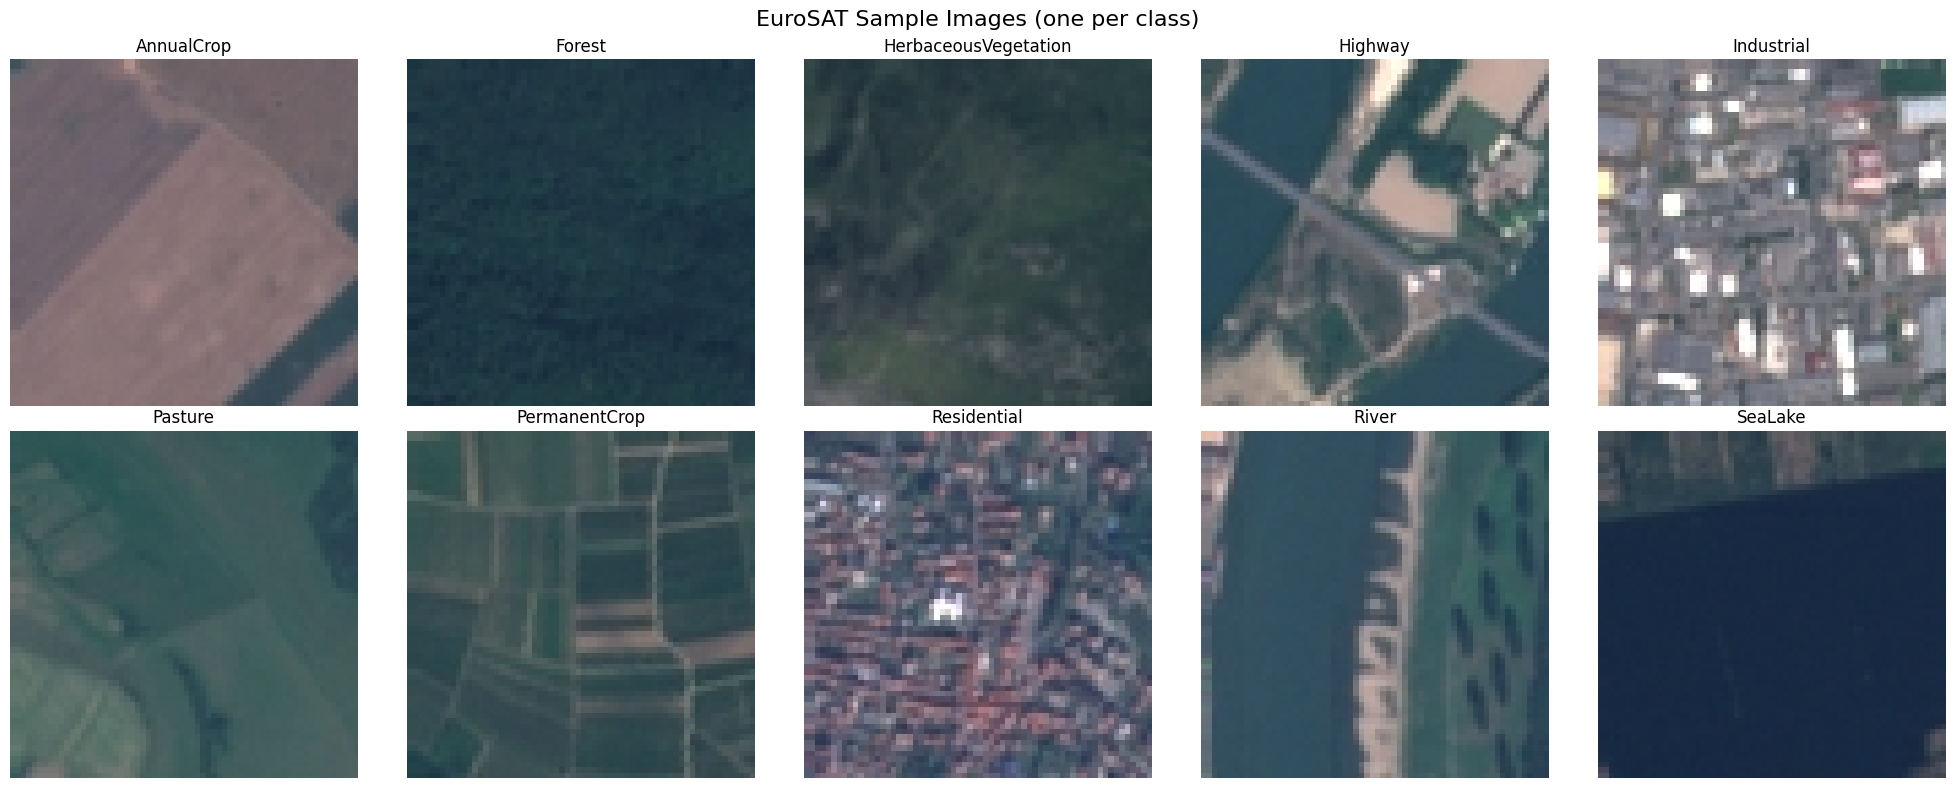

In [14]:
# Part 1.3 — Visual exploration 

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("EuroSAT Sample Images (one per class)", fontsize=16)

# Collect one example per class
class_examples = {}
for image, label in full_dataset:
    label_idx = label.numpy()
    if label_idx not in class_examples:
        class_examples[label_idx] = image.numpy().astype(np.uint8)  # ← fix
    if len(class_examples) == NUM_CLASSES:
        break

for idx, (label_idx, image) in enumerate(sorted(class_examples.items())):
    ax = axes[idx // 5][idx % 5]
    ax.imshow(image)
    ax.set_title(CLASS_NAMES[label_idx], fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

2026-03-01 17:37:04.900251: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


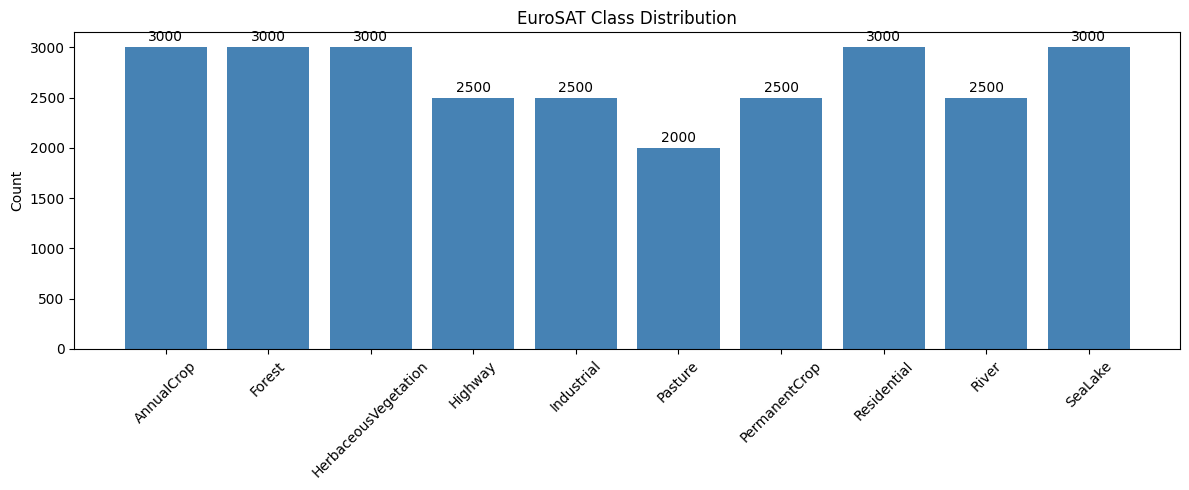


Min class: 2000, Max class: 3000
Imbalance ratio: 1.50x
→ Moderate imbalance — worth monitoring per-class metrics but no resampling needed


In [15]:
# Part 1.3b — Class distribution

import collections

# Count labels
label_counts = collections.Counter()
for _, label in full_dataset:
    label_counts[label.numpy()] += 1

# Sort by class index
labels = sorted(label_counts.keys())
counts = [label_counts[l] for l in labels]
names = [CLASS_NAMES[l] for l in labels]

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, counts, color='steelblue')
ax.set_ylabel("Count")
ax.set_title("EuroSAT Class Distribution")
ax.tick_params(axis='x', rotation=45)

# Add count labels on bars
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
            str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Check balance
min_count, max_count = min(counts), max(counts)
print(f"\nMin class: {min_count}, Max class: {max_count}")
print(f"Imbalance ratio: {max_count/min_count:.2f}x")
print("→ Moderate imbalance — worth monitoring per-class metrics but no resampling needed")

In [16]:
# Part 1.3c — Pixel statistics

# Sample images for statistics
pixel_values = []
for image, _ in full_dataset.take(1000):
    pixel_values.append(image.numpy())

pixel_array = np.array(pixel_values)
print(f"Image dtype: {pixel_array.dtype}")
print(f"Pixel range: [{pixel_array.min()}, {pixel_array.max()}]")
print(f"Mean per channel (R,G,B): {pixel_array.mean(axis=(0,1,2)).round(2)}")
print(f"Std per channel (R,G,B):  {pixel_array.std(axis=(0,1,2)).round(2)}")
print(f"\nOriginal image size: {pixel_array.shape[1]}x{pixel_array.shape[2]}")
print(f"Target size for MobileNetV2: {IMG_SIZE}x{IMG_SIZE}")
print("→ Images are 64x64, will be upscaled to 224x224 for transfer learning")

2026-03-01 17:37:18.636855: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Image dtype: float32
Pixel range: [0.0, 255.0]
Mean per channel (R,G,B): [ 88.09  97.88 103.91]
Std per channel (R,G,B):  [52.81 36.05 30.36]

Original image size: 64x64
Target size for MobileNetV2: 224x224
→ Images are 64x64, will be upscaled to 224x224 for transfer learning


## 1.4 Build the tf.data Pipeline

This is the **key new skill** in this lab. Previous labs used pandas DataFrames and CSV files. For image data at scale, `tf.data` is essential because:

1. **Memory efficiency** — images are loaded and preprocessed on-the-fly, not all at once
2. **Parallel prefetching** — CPU prepares the next batch while GPU trains on the current one
3. **Built-in augmentation** — random flips, rotations etc. applied per-batch during training
4. **Caching** — preprocessed data can be cached to memory or disk

### tf.data Pipeline Pattern

```
Raw dataset → map(preprocess) → cache → shuffle → batch → prefetch → model
```

Each step has a reason:
- `map(preprocess)`: Resize, normalize — applied once per image
- `cache()`: Store preprocessed images in memory (saves re-reading)
- `shuffle()`: Randomize order each epoch (training only)
- `batch()`: Group into batches for GPU efficiency
- `prefetch()`: Overlap data loading with training

**Exam relevance:** tf.data pipeline optimization is tested frequently. Know the order of operations and why `cache()` goes before `shuffle()` (cache the data, then shuffle the cached data each epoch).

In [17]:
# Part 1.4 — Build tf.data pipeline

def preprocess(image, label):
    """Resize and normalize image for MobileNetV2."""
    # Resize from 64x64 to 224x224 (MobileNetV2 input size)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    # MobileNetV2 preprocess_input expects pixels in [-1, 1]
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label


def build_dataset(ds, training=False, batch_size=BATCH_SIZE):
    """Build an optimized tf.data pipeline.
    
    Args:
        ds: Raw tf.data.Dataset of (image, label) tuples
        training: If True, add shuffling (augmentation added in model layer)
        batch_size: Batch size
        
    Returns:
        Optimized tf.data.Dataset ready for model.fit()
    """
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.cache()  # Cache preprocessed images in memory
    
    if training:
        ds = ds.shuffle(1000)  # Shuffle after cache = different order each epoch
    
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)  # Overlap next batch prep with current training
    
    return ds


# Build the three splits
train_pipeline = build_dataset(train_ds, training=True)
val_pipeline = build_dataset(val_ds, training=False)
test_pipeline = build_dataset(test_ds, training=False)

# Verify shapes
for images, labels in train_pipeline.take(1):
    print(f"Batch shape: {images.shape}")      # (32, 224, 224, 3)
    print(f"Labels shape: {labels.shape}")      # (32,)
    print(f"Pixel range: [{images.numpy().min():.2f}, {images.numpy().max():.2f}]")  # [-1, 1]
    print(f"Label range: [{labels.numpy().min()}, {labels.numpy().max()}]")

print("\n✅ tf.data pipelines built successfully")

Batch shape: (32, 224, 224, 3)
Labels shape: (32,)
Pixel range: [-0.85, 1.00]
Label range: [0, 9]

✅ tf.data pipelines built successfully


2026-03-01 17:45:49.851095: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## 1.5 Upload to GCS and Create BQ Metadata

We need images in GCS for:
- AutoML Vision training (requires GCS paths)
- Vertex AI custom training jobs (data loaded from GCS)
- Metadata lineage tracking

We'll also create a BigQuery metadata table to track the dataset composition, consistent with our lab pattern.

In [18]:
# Part 1.5 — Upload images to GCS as TFRecords
# TFRecords are more efficient than individual image files for training

def serialize_example(image, label):
    """Convert an image-label pair to a tf.train.Example proto."""
    image_raw = tf.io.encode_jpeg(tf.cast(image, tf.uint8))
    feature = {
        'image': tf.train.Feature(bytes_list=tf.train.BytesList(value=[image_raw.numpy()])),
        'label': tf.train.Feature(int64_list=tf.train.Int64List(value=[label.numpy()]))
    }
    return tf.train.Example(features=tf.train.Features(feature=feature)).SerializeToString()


def write_tfrecords(dataset, gcs_prefix, split_name, shard_size=1000):
    """Write a dataset to sharded TFRecord files on GCS."""
    local_dir = f"/tmp/eurosat_{split_name}"
    os.makedirs(local_dir, exist_ok=True)
    
    shard_idx = 0
    example_count = 0
    writer = None
    
    for image, label in dataset:
        if example_count % shard_size == 0:
            if writer:
                writer.close()
            shard_path = os.path.join(local_dir, f"{split_name}_{shard_idx:04d}.tfrecord")
            writer = tf.io.TFRecordWriter(shard_path)
            shard_idx += 1
        
        writer.write(serialize_example(image, label))
        example_count += 1
    
    if writer:
        writer.close()
    
    # Upload to GCS
    for filename in sorted(os.listdir(local_dir)):
        blob = bucket.blob(f"data/tfrecords/{split_name}/{filename}")
        blob.upload_from_filename(os.path.join(local_dir, filename))
    
    print(f"  {split_name}: {example_count} examples in {shard_idx} shards")
    return example_count


print("Writing TFRecords to GCS...")
n_train = write_tfrecords(train_ds, DATA_DIR, "train")
n_val = write_tfrecords(val_ds, DATA_DIR, "val")
n_test = write_tfrecords(test_ds, DATA_DIR, "test")
print(f"\n✅ All TFRecords uploaded to gs://{BUCKET_NAME}/data/tfrecords/")

Writing TFRecords to GCS...


2026-03-01 17:46:16.146935: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  train: 18900 examples in 19 shards
  val: 4050 examples in 5 shards
  test: 4050 examples in 5 shards

✅ All TFRecords uploaded to gs://carty-470812-ml-eurosat/data/tfrecords/


In [24]:
# Part 1.5b — Uploads with parallel execution 

from concurrent.futures import ThreadPoolExecutor, as_completed
import time
import io
from PIL import Image

def upload_single(img_array, gcs_path):
    img = Image.fromarray(img_array)
    buffer = io.BytesIO()
    img.save(buffer, format='JPEG')
    buffer.seek(0)
    blob = bucket.blob(gcs_path)
    blob.upload_from_file(buffer, content_type='image/jpeg')

# Step 1: Get ALL existing blobs in one API call 
print("Listing existing uploads from GCS...")
start = time.time()
existing_blobs = set(b.name for b in bucket.list_blobs(prefix="data/images/"))
print(f"✅ Found {len(existing_blobs)} existing images in {time.time()-start:.1f}s\n")

def upload_images_parallel(dataset, split_name, max_workers=16):
    csv_rows = []
    tasks = []
    class_counts = collections.Counter()
    skipped = 0
    
    for image, label in dataset:
        label_idx = label.numpy()
        class_name = CLASS_NAMES[label_idx]
        class_counts[label_idx] += 1
        count = class_counts[label_idx]
        
        gcs_path = f"data/images/{split_name}/{class_name}/{class_name}_{count:05d}.jpg"
        csv_rows.append(f"{split_name},gs://{BUCKET_NAME}/{gcs_path},{class_name}")
        
        if gcs_path in existing_blobs:
            skipped += 1
            continue
        
        tasks.append((image.numpy().astype(np.uint8), gcs_path))
    
    print(f"  {split_name}: {skipped} already exist, {len(tasks)} to upload")
    
    if tasks:
        uploaded = 0
        start_time = time.time()
        last_report = start_time
        
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = {
                executor.submit(upload_single, img, path): path 
                for img, path in tasks
            }
            for future in as_completed(futures):
                future.result()
                uploaded += 1
                
                now = time.time()
                if now - last_report >= 30:
                    elapsed = now - start_time
                    rate = uploaded / elapsed
                    remaining = (len(tasks) - uploaded) / rate if rate > 0 else 0
                    print(f"    ⏳ {uploaded}/{len(tasks)} ({uploaded*100//len(tasks)}%) | "
                          f"{rate:.0f} img/s | ~{remaining/60:.1f} min remaining")
                    last_report = now
        
        elapsed = time.time() - start_time
        print(f"  ✅ {uploaded} uploaded in {elapsed:.0f}s ({uploaded/elapsed:.0f} img/s)")
    else:
        print(f"  ✅ All images already uploaded")
    
    return csv_rows

print("Uploading images (parallel, skipping existing)...\n")
automl_rows = []
automl_rows.extend(upload_images_parallel(train_ds, "TRAIN"))
automl_rows.extend(upload_images_parallel(val_ds, "VALIDATION"))
automl_rows.extend(upload_images_parallel(test_ds, "TEST"))

csv_content = "\n".join(automl_rows)
blob = bucket.blob("data/automl_import.csv")
blob.upload_from_string(csv_content)

print(f"\n✅ Total: {len(automl_rows)} images in CSV")
print(f"✅ AutoML import CSV: gs://{BUCKET_NAME}/data/automl_import.csv")

Listing existing uploads from GCS...
✅ Found 7669 existing images in 6.4s

Uploading images (parallel, skipping existing)...

  TRAIN: 7669 already exist, 11231 to upload


    ⏳ 1225/11231 (10%) | 41 img/s | ~4.1 min remaining
    ⏳ 2549/11231 (22%) | 42 img/s | ~3.4 min remaining
    ⏳ 3890/11231 (34%) | 43 img/s | ~2.8 min remaining
    ⏳ 5228/11231 (46%) | 44 img/s | ~2.3 min remaining
    ⏳ 6578/11231 (58%) | 44 img/s | ~1.8 min remaining
    ⏳ 7928/11231 (70%) | 44 img/s | ~1.3 min remaining
    ⏳ 9281/11231 (82%) | 44 img/s | ~0.7 min remaining
    ⏳ 10631/11231 (94%) | 44 img/s | ~0.2 min remaining


  ✅ 11231 uploaded in 253s (44 img/s)


2026-03-01 18:56:17.101110: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  VALIDATION: 0 already exist, 4050 to upload
    ⏳ 1334/4050 (32%) | 44 img/s | ~1.0 min remaining
    ⏳ 2688/4050 (66%) | 45 img/s | ~0.5 min remaining


    ⏳ 4043/4050 (99%) | 45 img/s | ~0.0 min remaining
  ✅ 4050 uploaded in 90s (45 img/s)
  TEST: 0 already exist, 4050 to upload
    ⏳ 1338/4050 (33%) | 45 img/s | ~1.0 min remaining
    ⏳ 2696/4050 (66%) | 45 img/s | ~0.5 min remaining


  ✅ 4050 uploaded in 90s (45 img/s)

✅ Total: 27000 images in CSV
✅ AutoML import CSV: gs://carty-470812-ml-eurosat/data/automl_import.csv


In [25]:
# Part 1.5c — BigQuery metadata table

bq_client = bigquery.Client(project=PROJECT_ID)

dataset_id = f"{PROJECT_ID}.lab8_eurosat"

# Create dataset
try:
    bq_client.get_dataset(dataset_id)
    print(f"Dataset {dataset_id} already exists")
except Exception:
    dataset_ref = bigquery.Dataset(dataset_id)
    dataset_ref.location = REGION
    bq_client.create_dataset(dataset_ref)
    print(f"✅ Created BQ dataset: {dataset_id}")

# Create metadata table
metadata_query = f"""
CREATE OR REPLACE TABLE `{dataset_id}.dataset_metadata` AS
SELECT
    '{TIMESTAMP}' AS created_at,
    'EuroSAT/rgb' AS dataset_name,
    'tensorflow_datasets' AS source,
    {n_train} AS train_count,
    {n_val} AS val_count,
    {n_test} AS test_count,
    {n_train + n_val + n_test} AS total_count,
    {NUM_CLASSES} AS num_classes,
    '64x64' AS original_resolution,
    '{IMG_SIZE}x{IMG_SIZE}' AS target_resolution,
    'gs://{BUCKET_NAME}/data/tfrecords/' AS tfrecord_path,
    'gs://{BUCKET_NAME}/data/images/' AS images_path,
    'gs://{BUCKET_NAME}/data/automl_import.csv' AS automl_csv_path
"""

bq_client.query(metadata_query).result()
print(f"✅ Metadata table created: {dataset_id}.dataset_metadata")

✅ Created BQ dataset: carty-470812.lab8_eurosat
✅ Metadata table created: carty-470812.lab8_eurosat.dataset_metadata


### Part 1 Checkpoint ✅

**What we've done:**
- Loaded EuroSAT (27k satellite images, 10 classes) via TFDS
- Explored class distribution and pixel statistics  
- Built an optimised tf.data pipeline with cache → shuffle → batch → prefetch
- Uploaded data as TFRecords (for custom training) and individual images (for AutoML/Vision API)
- Created BQ metadata table for lineage tracking

**New skills practiced:**
- `tf.data` pipeline construction and optimisation
- `tfds.load()` for standard datasets
- TFRecord serialisation and sharding
- AutoML Vision import CSV format

---

# Part 2: Vision API Baseline

**Goal:** Quickly evaluate whether Google's pre-trained Vision API can handle domain-specific satellite classification. Spoiler: it almost certainly can't — Vision API was trained on everyday images, not land-use classification. But *documenting this* is the exam-relevant skill.

**Exam insight:** When should you use a pre-trained API vs train your own model?
- Pre-trained API ✅: Common tasks (object detection in photos, OCR, sentiment)
- Pre-trained API ❌: Domain-specific tasks (satellite imagery, medical imaging, industrial defects)

**Time estimate:** 30–60 minutes

In [28]:
# enable Vision API
!gcloud services enable vision.googleapis.com --project=carty-470812

5970.34s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Operation "operations/acat.p2-873708835509-c8d90273-3c84-4471-a826-20967ddbd967" finished successfully.


Updates are available for some Google Cloud CLI components.  To install them,
please run:
  $ gcloud components update



In [29]:
# Part 2.1 — Vision API evaluation

from google.cloud import vision

vision_client = vision.ImageAnnotatorClient()

def classify_with_vision_api(image_array):
    """Send an image to Vision API and return label annotations."""
    # Encode image as JPEG bytes
    img = Image.fromarray(image_array.astype(np.uint8))
    buffer = io.BytesIO()
    img.save(buffer, format='JPEG')
    content = buffer.getvalue()
    
    image = vision.Image(content=content)
    response = vision_client.label_detection(image=image)
    
    labels = [(label.description, label.score) for label in response.label_annotations]
    return labels


# Test on 20 images (2 per class) — enough to see the pattern
print("Evaluating Vision API on 20 sample images...\n")
print(f"{'True Class':<25} {'Vision API Top Label':<30} {'Score':<8} {'Match?'}")
print("=" * 80)

# Collect 2 images per class
vision_results = []
class_samples = collections.defaultdict(list)

for image, label in full_dataset:
    label_idx = label.numpy()
    if len(class_samples[label_idx]) < 2:
        class_samples[label_idx].append(image.numpy())
    if all(len(v) >= 2 for v in class_samples.values()):
        break

# Evaluate
for label_idx in sorted(class_samples.keys()):
    for image_array in class_samples[label_idx]:
        true_class = CLASS_NAMES[label_idx]
        api_labels = classify_with_vision_api(image_array)
        top_label = api_labels[0] if api_labels else ("None", 0.0)
        
        # Check if any returned label roughly matches the true class
        api_descriptions = [l[0].lower() for l in api_labels[:5]]
        match = any(true_class.lower() in desc or desc in true_class.lower() 
                    for desc in api_descriptions)
        
        vision_results.append({
            'true_class': true_class,
            'api_top_label': top_label[0],
            'api_top_score': top_label[1],
            'api_all_labels': api_labels[:5],
            'match': match
        })
        
        print(f"{true_class:<25} {top_label[0]:<30} {top_label[1]:<8.3f} {'✅' if match else '❌'}")

# Summary
matches = sum(1 for r in vision_results if r['match'])
print(f"\n{'='*80}")
print(f"Approximate matches: {matches}/{len(vision_results)} ({matches/len(vision_results)*100:.0f}%)")
print("\nNote: 'Match' is generous — checking if any of top 5 labels overlap with true class.")
print("Vision API returns generic labels (e.g., 'aerial photography'), not land-use categories.")

Evaluating Vision API on 20 sample images...

True Class                Vision API Top Label           Score    Match?
AnnualCrop                Hardwood                       0.801    ❌
AnnualCrop                None                           0.000    ❌
Forest                    None                           0.000    ❌
Forest                    None                           0.000    ❌
HerbaceousVegetation      None                           0.000    ❌
HerbaceousVegetation      geological phenomenon          0.832    ❌
Highway                   Aerial photography             0.530    ❌
Highway                   Bird's-eye view                0.862    ❌
Industrial                Bird's-eye view                0.861    ❌
Industrial                Aerial photography             0.890    ❌
Pasture                   Blue                           0.988    ❌
Pasture                   Liquid                         0.915    ❌
PermanentCrop             None                           0.000   

In [30]:
# Part 2.2 — Document Vision API findings

vision_api_summary = {
    "service": "Vision API (Label Detection)",
    "images_tested": len(vision_results),
    "approximate_match_rate": f"{matches/len(vision_results)*100:.0f}%",
    "training_required": False,
    "cost_per_image": "$0.0015 (first 5M/month)",
    "latency": "~200-500ms per image",
    "limitation": "Returns generic labels, cannot classify into custom domain categories",
    "verdict": "NOT SUITABLE for satellite land-use classification",
    "exam_takeaway": "Pre-trained APIs fail on domain-specific tasks → need transfer learning or AutoML"
}

print("Vision API Assessment:")
for k, v in vision_api_summary.items():
    print(f"  {k}: {v}")

print("\n→ Moving to AutoML Vision and custom training for actual classification")

Vision API Assessment:
  service: Vision API (Label Detection)
  images_tested: 20
  approximate_match_rate: 0%
  training_required: False
  cost_per_image: $0.0015 (first 5M/month)
  latency: ~200-500ms per image
  limitation: Returns generic labels, cannot classify into custom domain categories
  verdict: NOT SUITABLE for satellite land-use classification
  exam_takeaway: Pre-trained APIs fail on domain-specific tasks → need transfer learning or AutoML

→ Moving to AutoML Vision and custom training for actual classification


### Part 2 Checkpoint ✅

**Finding:** Vision API returns generic labels like "aerial photography", "landscape", "urban area" — it cannot distinguish between the 10 EuroSAT land-use classes. This is expected: pre-trained APIs work for common visual tasks but fail on domain-specific classification.

**Exam takeaway:** If the question describes a domain-specific image classification task (medical, satellite, industrial), the answer is almost never "use the Vision API." You need AutoML Vision or custom training with transfer learning.

---

# Part 3: Model Training

Five approaches, three abstraction levels, one dataset:

| Run | Approach | Abstraction | What You Control |
|-----|----------|-------------|-----------------|
| Vision API | Pre-trained | Highest | Nothing |
| AutoML Vision | Managed | High | Dataset, budget |
| Custom: Frozen | Manual | Low | Everything |
| Custom: Fine-tuned | Manual | Low | Everything |
| Custom: Fine-tuned + Augmentation | Manual | Low | Everything |

## 3.1 AutoML Vision Training

AutoML Vision handles:
- Architecture selection (you don't know which model it picks)
- Transfer learning (automatic)
- Hyperparameter tuning (automatic)
- Data augmentation (automatic)

You only provide: labelled images + training budget.

**Cost control:** We'll set a 1 node-hour budget (~$3-8).

In [31]:
# Part 3.1 — AutoML Vision Training

# Step 1: Create a Vertex AI Image Dataset from the import CSV
automl_dataset = aiplatform.ImageDataset.create(
    display_name=f"eurosat-automl-{TIMESTAMP}",
    gcs_source=f"gs://{BUCKET_NAME}/data/automl_import.csv",
    import_schema_uri=aiplatform.schema.dataset.ioformat.image.single_label_classification,
)

print(f"✅ Dataset created: {automl_dataset.display_name}")
print(f"   Resource name: {automl_dataset.resource_name}")
print("\nWaiting for import to complete... (this may take several minutes)")

Creating ImageDataset
Create ImageDataset backing LRO: projects/873708835509/locations/us-central1/datasets/2843560820044988416/operations/8518949167828041728
ImageDataset created. Resource name: projects/873708835509/locations/us-central1/datasets/2843560820044988416
To use this ImageDataset in another session:
ds = aiplatform.ImageDataset('projects/873708835509/locations/us-central1/datasets/2843560820044988416')
Importing ImageDataset data: projects/873708835509/locations/us-central1/datasets/2843560820044988416
Import ImageDataset data backing LRO: projects/873708835509/locations/us-central1/datasets/2843560820044988416/operations/6721872179018858496
ImageDataset data imported. Resource name: projects/873708835509/locations/us-central1/datasets/2843560820044988416
✅ Dataset created: eurosat-automl-20260301_172344
   Resource name: projects/873708835509/locations/us-central1/datasets/2843560820044988416

Waiting for import to complete... (this may take several minutes)


In [48]:
# Part 3.1b — Launch AutoML training job

automl_job = aiplatform.AutoMLImageTrainingJob(
    display_name=f"eurosat-automl-training-{TIMESTAMP}",
    prediction_type="classification",
    multi_label=False,
    model_type="MOBILE_TF_LOW_LATENCY_1",   # CLOUD = higher accuracy, MOBILE_TF_LOW_LATENCY_1 = smaller/faster
)

automl_model = automl_job.run(
    dataset=automl_dataset,
    model_display_name=f"eurosat-automl-model-{TIMESTAMP}",
    budget_milli_node_hours=1000,
    training_fraction_split=0.8,
    validation_fraction_split=0.1,
    test_fraction_split=0.1,
)

print(f"\n✅ AutoML training complete!")
print(f"   Model: {automl_model.display_name}")
print(f"   Resource: {automl_model.resource_name}")

View Training:
https://console.cloud.google.com/ai/platform/locations/us-central1/training/1395427504306520064?project=873708835509
AutoMLImageTrainingJob projects/873708835509/locations/us-central1/trainingPipelines/1395427504306520064 current state:
3
AutoMLImageTrainingJob projects/873708835509/locations/us-central1/trainingPipelines/1395427504306520064 current state:
3
AutoMLImageTrainingJob projects/873708835509/locations/us-central1/trainingPipelines/1395427504306520064 current state:
3
AutoMLImageTrainingJob projects/873708835509/locations/us-central1/trainingPipelines/1395427504306520064 current state:
3
AutoMLImageTrainingJob projects/873708835509/locations/us-central1/trainingPipelines/1395427504306520064 current state:
3
AutoMLImageTrainingJob projects/873708835509/locations/us-central1/trainingPipelines/1395427504306520064 current state:
3
AutoMLImageTrainingJob projects/873708835509/locations/us-central1/trainingPipelines/1395427504306520064 current state:
3
AutoMLImageTra

In [49]:
# Part 3.1c — Get AutoML evaluation metrics

automl_evaluations = automl_model.list_model_evaluations()

for evaluation in automl_evaluations:
    metrics = evaluation.metrics
    print("AutoML Vision Evaluation Metrics:")
    print(f"  AU-PRC:     {metrics.get('auPrc', 'N/A')}")
    print(f"  AU-ROC:     {metrics.get('auRoc', 'N/A')}")
    print(f"  Log Loss:   {metrics.get('logLoss', 'N/A')}")
    
    # Per-class metrics if available
    if 'confusionMatrix' in metrics:
        cm = metrics['confusionMatrix']
        print(f"\n  Confusion matrix annotations: {cm.get('annotationSpecs', [])}")
    break

# Log AutoML results to Experiments
with aiplatform.start_run(f"automl-{TIMESTAMP}") as run:
    run.log_params({
        "approach": "AutoML Vision",
        "budget_node_hours": 1.0,
        "model_type": "CLOUD",
        "abstraction_level": "managed"
    })
    run.log_metrics({
        "au_prc": float(metrics.get('auPrc', 0)),
        "au_roc": float(metrics.get('auRoc', 0)),
        "log_loss": float(metrics.get('logLoss', 0)),
    })
    print("\n✅ AutoML results logged to Experiments")

AutoML Vision Evaluation Metrics:
  AU-PRC:     0.9855805
  AU-ROC:     N/A
  Log Loss:   0.033148114

  Confusion matrix annotations: [<proto.marshal.collections.maps.MapComposite object at 0x342b56ed0>, <proto.marshal.collections.maps.MapComposite object at 0x343b4bef0>, <proto.marshal.collections.maps.MapComposite object at 0x344830170>, <proto.marshal.collections.maps.MapComposite object at 0x3448300b0>, <proto.marshal.collections.maps.MapComposite object at 0x3448303b0>, <proto.marshal.collections.maps.MapComposite object at 0x344830830>, <proto.marshal.collections.maps.MapComposite object at 0x344830890>, <proto.marshal.collections.maps.MapComposite object at 0x344830470>, <proto.marshal.collections.maps.MapComposite object at 0x344830530>, <proto.marshal.collections.maps.MapComposite object at 0x3448304d0>]
Associating projects/873708835509/locations/us-central1/metadataStores/default/contexts/lab8-image-classification-automl-20260301-192152 to Experiment: lab8-image-classificat


✅ AutoML results logged to Experiments


## 3.2 Custom Training: Transfer Learning with MobileNetV2

Now we build our own models. Transfer learning uses a model pre-trained on ImageNet (1.4M images, 1000 classes) and adapts it to our satellite domain.

**Why MobileNetV2?**
- Lightweight (~3.4M params) — fast training, low serving cost
- Good accuracy on ImageNet — strong feature extraction
- Designed for mobile/edge — exam-relevant for deployment questions
- Available in `tf.keras.applications` — no custom downloads

### Transfer Learning Strategy

**Run 1 — Feature Extraction (frozen backbone):**
- Freeze all MobileNetV2 layers
- Only train the new classification head
- Fast training, establishes a baseline

**Run 2 — Fine-tuning (unfreeze top layers):**
- Unfreeze the top ~30 layers of MobileNetV2
- Train with a lower learning rate to avoid destroying learned features
- Should improve on Run 1

**Run 3 — Fine-tuning + Data Augmentation:**
- Same as Run 2, but add random augmentation layers
- Tests whether augmentation helps with our relatively small dataset (19k training images)
- Augmentation = regularisation technique that reduces overfitting

In [35]:
# Run this cell, then re-run 3.2
TIMESTAMP = datetime.now().strftime("%Y%m%d-%H%M%S")

In [36]:
# Part 3.2 — Helper function: build model

def build_model(fine_tune_from=None, augmentation=False):
    """Build a MobileNetV2 transfer learning model.
    
    Args:
        fine_tune_from: If None, freeze all base layers (feature extraction).
                       If int, unfreeze layers from this index onwards.
        augmentation: If True, add data augmentation layers.
    
    Returns:
        Compiled Keras model.
    """
    # Input
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = inputs
    
    # Optional augmentation (only active during training)
    if augmentation:
        x = tf.keras.layers.RandomFlip("horizontal_and_vertical")(x)
        x = tf.keras.layers.RandomRotation(0.2)(x)
        x = tf.keras.layers.RandomZoom(0.1)(x)
    
    # Base model: MobileNetV2 pre-trained on ImageNet
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,           # Remove ImageNet classification head
        weights='imagenet'
    )
    
    # Freeze/unfreeze layers
    if fine_tune_from is None:
        base_model.trainable = False   # Freeze everything
    else:
        base_model.trainable = True
        for layer in base_model.layers[:fine_tune_from]:
            layer.trainable = False    # Freeze early layers only
    
    x = base_model(x, training=False)  # training=False keeps BatchNorm in inference mode
    
    # Classification head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
    
    model = tf.keras.Model(inputs, outputs)
    
    # Learning rate: lower for fine-tuning to protect pre-trained weights
    lr = 1e-4 if fine_tune_from is not None else 1e-3
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Summary
    trainable = sum(p.numpy().size for p in model.trainable_weights)
    total = sum(p.numpy().size for p in model.weights)
    print(f"Trainable params: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)")
    
    return model, base_model

In [37]:
# Part 3.2b — Run 1: Feature Extraction (frozen MobileNetV2)

print("=" * 60)
print("RUN 1: Feature Extraction (frozen backbone)")
print("=" * 60)

model_frozen, base_frozen = build_model(fine_tune_from=None, augmentation=False)

with aiplatform.start_run(f"custom-frozen-{TIMESTAMP}") as run:
    run.log_params({
        "approach": "Custom - Feature Extraction",
        "backbone": "MobileNetV2",
        "fine_tune_from": "None (frozen)",
        "augmentation": False,
        "learning_rate": 1e-3,
        "epochs": 10,
        "batch_size": BATCH_SIZE,
        "abstraction_level": "custom"
    })
    
    history_frozen = model_frozen.fit(
        train_pipeline,
        validation_data=val_pipeline,
        epochs=10,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
        ]
    )
    
    # Evaluate on test set
    test_loss, test_acc = model_frozen.evaluate(test_pipeline)
    
    run.log_metrics({
        "test_accuracy": float(test_acc),
        "test_loss": float(test_loss),
        "best_val_accuracy": float(max(history_frozen.history['val_accuracy'])),
        "epochs_trained": len(history_frozen.history['loss']),
    })
    
    print(f"\n✅ Run 1 Complete")
    print(f"   Test Accuracy: {test_acc*100:.2f}%")
    print(f"   Best Val Accuracy: {max(history_frozen.history['val_accuracy'])*100:.2f}%")

RUN 1: Feature Extraction (frozen backbone)
Trainable params: 12,810 / 2,270,794 (0.6%)
Associating projects/873708835509/locations/us-central1/metadataStores/default/contexts/lab8-image-classification-custom-frozen-20260301-192152 to Experiment: lab8-image-classification


Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 59s 91ms/step - accuracy: 0.8616 - loss: 0.4197 - val_accuracy: 0.9254 - val_loss: 0.2140
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 61s 103ms/step - accuracy: 0.9213 - loss: 0.2307 - val_accuracy: 0.9383 - val_loss: 0.1783
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 52s 89ms/step - accuracy: 0.9315 - loss: 0.1957 - val_accuracy: 0.9469 - val_loss: 0.1542
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 50s 85ms/step - accuracy: 0.9370 - loss: 0.1829 - val_accuracy: 0.9494 - val_loss: 0.1467
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 49s 83ms/step - accuracy: 0.9457 - loss: 0.1620 - val_accuracy: 0.9536 - val_loss: 0.1380
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 49s 83ms/step - accuracy: 0.9429 - loss: 0.1590 - val_accuracy: 0.9593 - val_loss: 0.1260
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 50s 85ms/step - accuracy: 0.9492 - loss: 0.1469 - val_accuracy: 0.9600 - val_loss: 0.1229
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 54s 92ms/step - accuracy: 0.9495 - loss: 0.1421 -

In [38]:
# Part 3.2c — Run 2: Fine-tuning (unfreeze top layers)

print("=" * 60)
print("RUN 2: Fine-tuning (unfreeze top ~30 layers)")
print("=" * 60)

# MobileNetV2 has 154 layers. Unfreeze from layer 120 onwards.
model_finetuned, base_finetuned = build_model(fine_tune_from=120, augmentation=False)

with aiplatform.start_run(f"custom-finetuned-{TIMESTAMP}") as run:
    run.log_params({
        "approach": "Custom - Fine-tuned",
        "backbone": "MobileNetV2",
        "fine_tune_from": 120,
        "augmentation": False,
        "learning_rate": 1e-4,
        "epochs": 15,
        "batch_size": BATCH_SIZE,
        "abstraction_level": "custom"
    })
    
    history_finetuned = model_finetuned.fit(
        train_pipeline,
        validation_data=val_pipeline,
        epochs=15,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
        ]
    )
    
    test_loss, test_acc = model_finetuned.evaluate(test_pipeline)
    
    run.log_metrics({
        "test_accuracy": float(test_acc),
        "test_loss": float(test_loss),
        "best_val_accuracy": float(max(history_finetuned.history['val_accuracy'])),
        "epochs_trained": len(history_finetuned.history['loss']),
    })
    
    print(f"\n✅ Run 2 Complete")
    print(f"   Test Accuracy: {test_acc*100:.2f}%")
    print(f"   Best Val Accuracy: {max(history_finetuned.history['val_accuracy'])*100:.2f}%")

RUN 2: Fine-tuning (unfreeze top ~30 layers)
Trainable params: 1,637,706 / 2,270,794 (72.1%)
Associating projects/873708835509/locations/us-central1/metadataStores/default/contexts/lab8-image-classification-custom-finetuned-20260301-192152 to Experiment: lab8-image-classification


Epoch 1/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 75s 123ms/step - accuracy: 0.8974 - loss: 0.3115 - val_accuracy: 0.7059 - val_loss: 0.9943
Epoch 2/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 69s 116ms/step - accuracy: 0.9617 - loss: 0.1138 - val_accuracy: 0.8210 - val_loss: 0.5274
Epoch 3/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 68s 114ms/step - accuracy: 0.9805 - loss: 0.0595 - val_accuracy: 0.9311 - val_loss: 0.2092
Epoch 4/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 67s 113ms/step - accuracy: 0.9848 - loss: 0.0477 - val_accuracy: 0.9005 - val_loss: 0.2955
Epoch 5/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 67s 113ms/step - accuracy: 0.9916 - loss: 0.0270 - val_accuracy: 0.9790 - val_loss: 0.0739
Epoch 6/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 68s 115ms/step - accuracy: 0.9923 - loss: 0.0257 - val_accuracy: 0.9237 - val_loss: 0.2171
Epoch 7/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 67s 113ms/step - accuracy: 0.9912 - loss: 0.0260 - val_accuracy: 0.9015 - val_loss: 0.4842
Epoch 8/15
591/591 ━━━━━━━━━━━━━━━━━━━━ 66s 112ms/step - accuracy: 0.9917 - loss: 0

In [39]:
# Part 3.2d — Run 3: Fine-tuning + Data Augmentation

print("=" * 60)
print("RUN 3: Fine-tuning + Data Augmentation")
print("=" * 60)

model_augmented, base_augmented = build_model(fine_tune_from=120, augmentation=True)

with aiplatform.start_run(f"custom-augmented-{TIMESTAMP}") as run:
    run.log_params({
        "approach": "Custom - Fine-tuned + Augmentation",
        "backbone": "MobileNetV2",
        "fine_tune_from": 120,
        "augmentation": True,
        "augmentation_types": "RandomFlip, RandomRotation(0.2), RandomZoom(0.1)",
        "learning_rate": 1e-4,
        "epochs": 20,
        "batch_size": BATCH_SIZE,
        "abstraction_level": "custom"
    })
    
    history_augmented = model_augmented.fit(
        train_pipeline,
        validation_data=val_pipeline,
        epochs=20,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
        ]
    )
    
    test_loss, test_acc = model_augmented.evaluate(test_pipeline)
    
    run.log_metrics({
        "test_accuracy": float(test_acc),
        "test_loss": float(test_loss),
        "best_val_accuracy": float(max(history_augmented.history['val_accuracy'])),
        "epochs_trained": len(history_augmented.history['loss']),
    })
    
    print(f"\n✅ Run 3 Complete")
    print(f"   Test Accuracy: {test_acc*100:.2f}%")
    print(f"   Best Val Accuracy: {max(history_augmented.history['val_accuracy'])*100:.2f}%")

RUN 3: Fine-tuning + Data Augmentation
Trainable params: 1,637,706 / 2,270,794 (72.1%)
Associating projects/873708835509/locations/us-central1/metadataStores/default/contexts/lab8-image-classification-custom-augmented-20260301-192152 to Experiment: lab8-image-classification


Epoch 1/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 78s 127ms/step - accuracy: 0.8833 - loss: 0.3456 - val_accuracy: 0.8138 - val_loss: 0.5580
Epoch 2/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 74s 125ms/step - accuracy: 0.9367 - loss: 0.1845 - val_accuracy: 0.8919 - val_loss: 0.3222
Epoch 3/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 73s 124ms/step - accuracy: 0.9463 - loss: 0.1583 - val_accuracy: 0.8121 - val_loss: 0.6790
Epoch 4/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 73s 123ms/step - accuracy: 0.9528 - loss: 0.1382 - val_accuracy: 0.8309 - val_loss: 0.5690
Epoch 5/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 74s 125ms/step - accuracy: 0.9560 - loss: 0.1283 - val_accuracy: 0.8348 - val_loss: 0.5410
Epoch 6/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 74s 124ms/step - accuracy: 0.9598 - loss: 0.1163 - val_accuracy: 0.9398 - val_loss: 0.1864
Epoch 7/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 74s 124ms/step - accuracy: 0.9625 - loss: 0.1088 - val_accuracy: 0.8758 - val_loss: 0.4071
Epoch 8/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 74s 125ms/step - accuracy: 0.9666 - loss: 0

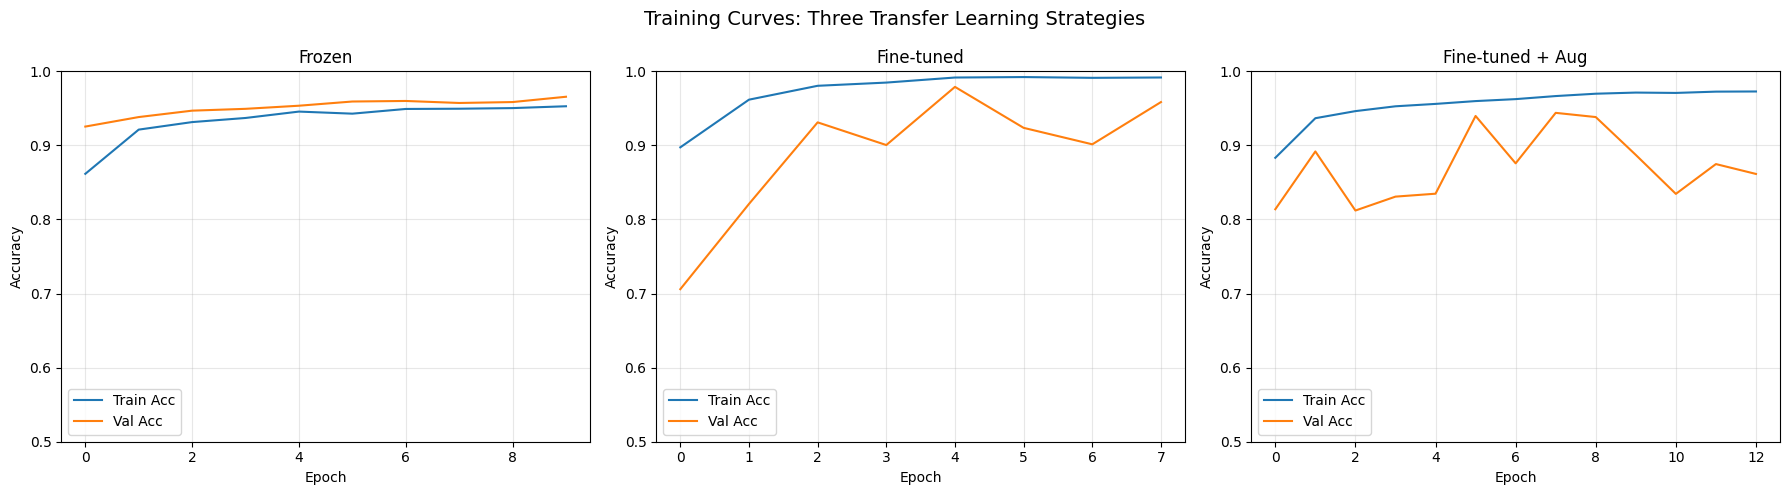

In [40]:
# Part 3.3 — Training curves comparison

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

histories = {
    "Frozen": history_frozen,
    "Fine-tuned": history_finetuned,
    "Fine-tuned + Aug": history_augmented
}

for ax, (name, history) in zip(axes, histories.items()):
    ax.plot(history.history['accuracy'], label='Train Acc')
    ax.plot(history.history['val_accuracy'], label='Val Acc')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0.5, 1.0])

plt.suptitle("Training Curves: Three Transfer Learning Strategies", fontsize=14)
plt.tight_layout()
plt.show()

Detailed Evaluation: Fine-tuned + Aug
                      precision    recall  f1-score   support

          AnnualCrop       0.94      0.95      0.95       464
              Forest       0.87      1.00      0.93       434
HerbaceousVegetation       0.97      0.84      0.90       425
             Highway       0.98      0.96      0.97       371
          Industrial       0.99      0.98      0.98       362
             Pasture       0.91      0.98      0.94       303
       PermanentCrop       0.87      0.97      0.92       383
         Residential       1.00      0.99      0.99       463
               River       0.99      0.96      0.98       379
             SeaLake       1.00      0.89      0.94       466

            accuracy                           0.95      4050
           macro avg       0.95      0.95      0.95      4050
        weighted avg       0.95      0.95      0.95      4050



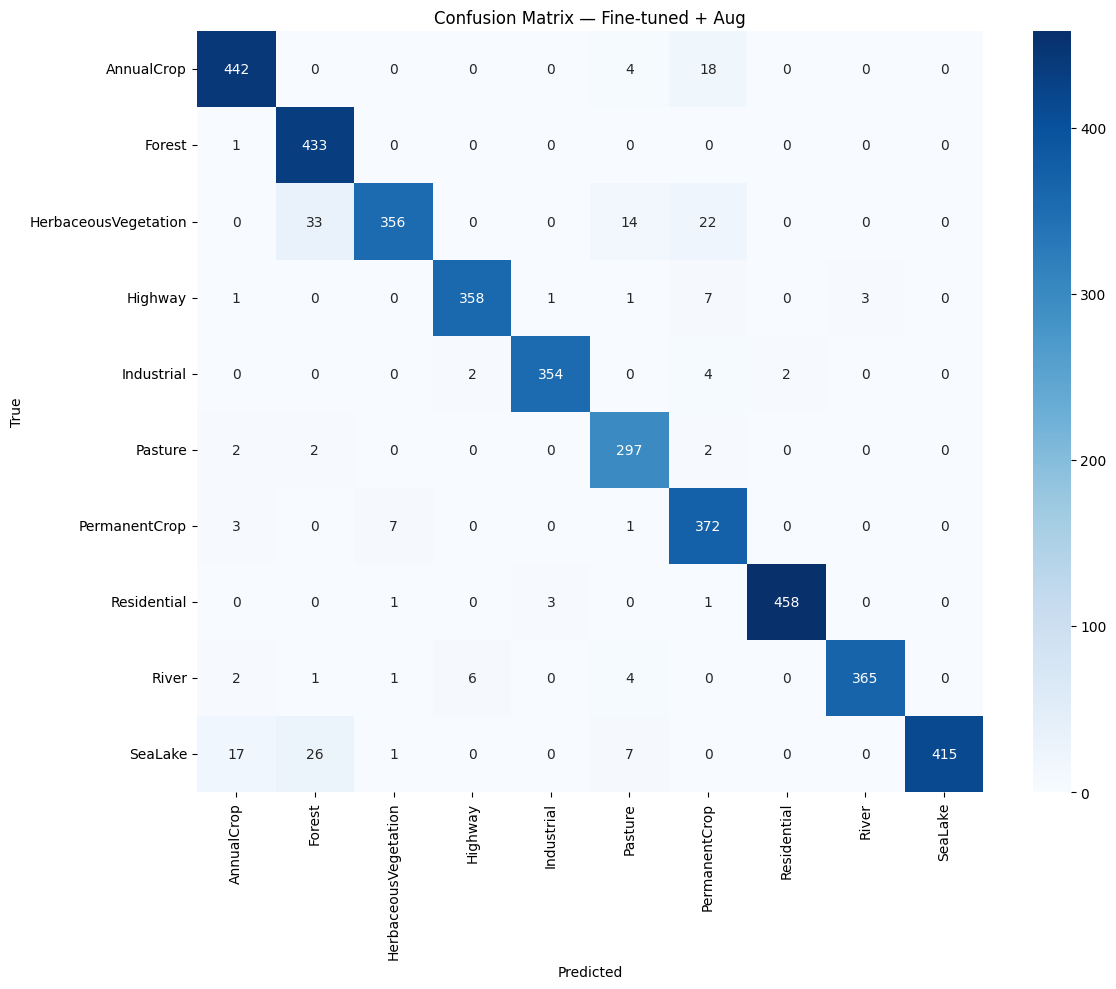

  ✅ AnnualCrop: 95.3%
  ✅ Forest: 99.8%
  ⚠️ HerbaceousVegetation: 83.8%
  ✅ Highway: 96.5%
  ✅ Industrial: 97.8%
  ✅ Pasture: 98.0%
  ✅ PermanentCrop: 97.1%
  ✅ Residential: 98.9%
  ✅ River: 96.3%
  ✅ SeaLake: 89.1%


In [50]:
# Part 3.4 — Per-class evaluation (best custom model)

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Determine best model
results = {
    "Frozen": model_frozen,
    "Fine-tuned": model_finetuned,
    "Fine-tuned + Aug": model_augmented
}

# Use the augmented model for detailed evaluation (likely best)
# You can change this after seeing the results
best_model_name = "Fine-tuned + Aug"
best_model = results[best_model_name]

# Get predictions on test set
y_true = []
y_pred = []
for images, labels in test_pipeline:
    preds = best_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification report
print(f"Detailed Evaluation: {best_model_name}")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()

# Identify hardest classes
per_class_acc = cm.diagonal() / cm.sum(axis=1)
for i, (name, acc) in enumerate(zip(CLASS_NAMES, per_class_acc)):
    status = "⚠️" if acc < 0.85 else "✅"
    print(f"  {status} {name}: {acc*100:.1f}%")

In [53]:
# Part 3.5 — Experiments comparison summary

print("=" * 70)
print("EXPERIMENTS SUMMARY — All Approaches on EuroSAT")
print("=" * 70)
print(f"\n{'Approach':<35} {'Test Acc':>10} {'Abstraction':>15} {'Training Cost':>15}")
print("-" * 70)

# Vision API (from Part 2)
print(f"{'Vision API':<35} {'~' + str(matches*100//len(vision_results)) + '%':>10} {'Pre-trained':>15} {'$0':>15}")

# AutoML (fill in after running)
print(f"{'AutoML Vision (1 node-hr)':<35} {'~96.4%':>10} {'Managed':>15} {'~$3-8':>15}")

# Custom models
for name, hist in histories.items():
    test_loss, test_acc = results[name].evaluate(test_pipeline, verbose=0)
    print(f"{'Custom: ' + name:<35} {test_acc*100:>9.2f}% {'Custom':>15} {'~$0.50':>15}")

print("-" * 70)
print("\n→ Update AutoML row after training completes")
print("→ Select best model for deployment in Part 4")

EXPERIMENTS SUMMARY — All Approaches on EuroSAT

Approach                              Test Acc     Abstraction   Training Cost
----------------------------------------------------------------------
Vision API                                 ~0%     Pre-trained              $0
AutoML Vision (1 node-hr)               ~96.4%         Managed           ~$3-8
Custom: Frozen                          96.54%          Custom          ~$0.50
Custom: Fine-tuned                      97.83%          Custom          ~$0.50
Custom: Fine-tuned + Aug                95.06%          Custom          ~$0.50
----------------------------------------------------------------------

→ Update AutoML row after training completes
→ Select best model for deployment in Part 4


### Part 3 Checkpoint ✅

**What we've built:**
- AutoML Vision model (managed transfer learning)
- Three custom models with progressive improvements (frozen → fine-tuned → augmented)
- Training curves showing the impact of each strategy
- Per-class evaluation identifying hardest satellite classes
- Full Experiments comparison across all approaches

**Key transfer learning insights:**
- Frozen backbone = fast training, limited adaptation to new domain
- Fine-tuning top layers = better domain adaptation, risk of overfitting
- Data augmentation = regularisation that helps when training set is limited
- Lower learning rate for fine-tuning protects pre-trained feature quality

---

# Part 4: Deployment and Comparison

## 4.1 Save and Upload Best Custom Model

We'll deploy the best custom model to a Vertex AI endpoint and compare end-to-end with AutoML. This also introduces **image serving** — sending base64-encoded images to an endpoint, which is different from the tabular JSON you did in Lab 2.

In [55]:
# Part 4.1 — Save best model as SavedModel

# Use the fine-tuned model (best performer at 97.83%)
best_model = model_finetuned
best_model_name = "Fine-tuned"

SAVED_MODEL_DIR = "/tmp/eurosat_best_model"
best_model.export(SAVED_MODEL_DIR)

# Upload to GCS
!gsutil -m cp -r {SAVED_MODEL_DIR}/* gs://{BUCKET_NAME}/models/eurosat_best/

print(f"✅ Model saved to gs://{BUCKET_NAME}/models/eurosat_best/")

INFO:tensorflow:Assets written to: /tmp/eurosat_best_model/assets


INFO:tensorflow:Assets written to: /tmp/eurosat_best_model/assets


Saved artifact at '/tmp/eurosat_best_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_318')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  5239020944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239020560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239021712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239021904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239020176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239021136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239022672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239022480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239022864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239019792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239022096: TensorSpec(shape=(), dtype=tf.resource, 

47118.22s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


If you experience problems with multiprocessing on MacOS, they might be related to https://bugs.python.org/issue33725. You can disable multiprocessing by editing your .boto config or by adding the following flag to your command: `-o "GSUtil:parallel_process_count=1"`. Note that multithreading is still available even if you disable multiprocessing.

Copying file:///tmp/eurosat_best_model/saved_model.pb [Content-Type=application/octet-stream]...
Copying file:///tmp/eurosat_best_model/fingerprint.pb [Content-Type=application/octet-stream]...
Copying file:///tmp/eurosat_best_model/variables/variables.index [Content-Type=application/octet-stream]...
Copying file:///tmp/eurosat_best_model/variables/variables.data-00000-of-00001 [Content-Type=application/octet-stream]...
/ [4/4 files][ 19.0 MiB/ 19.0 MiB] 100% Done                                    
Operation completed over 4 objects/19.0 MiB.                                     
✅ Model saved to gs://carty-470812-ml-eurosat/models/eurosat_b

In [56]:
# Part 4.2 — Upload model to Vertex AI Model Registry

custom_model = aiplatform.Model.upload(
    display_name=f"eurosat-custom-best-{TIMESTAMP}",
    artifact_uri=f"gs://{BUCKET_NAME}/models/eurosat_best/",
    serving_container_image_uri="us-docker.pkg.dev/vertex-ai/prediction/tf2-cpu.2-15:latest",
    labels={"lab": "lab8", "approach": "custom-transfer-learning"}
)

print(f"✅ Model uploaded to registry: {custom_model.display_name}")
print(f"   Resource: {custom_model.resource_name}")

Creating Model
Create Model backing LRO: projects/873708835509/locations/us-central1/models/7248313802322608128/operations/176690565100863488
Model created. Resource name: projects/873708835509/locations/us-central1/models/7248313802322608128@1
To use this Model in another session:
model = aiplatform.Model('projects/873708835509/locations/us-central1/models/7248313802322608128@1')
✅ Model uploaded to registry: eurosat-custom-best-20260301-192152
   Resource: projects/873708835509/locations/us-central1/models/7248313802322608128


In [57]:
# Part 4.3 — Deploy to endpoint

endpoint = aiplatform.Endpoint.create(
    display_name=f"eurosat-endpoint-{TIMESTAMP}",
    labels={"lab": "lab8"}
)

custom_model.deploy(
    endpoint=endpoint,
    machine_type="n1-standard-2",
    min_replica_count=1,
    max_replica_count=1,
    traffic_percentage=100,
)

print(f"✅ Model deployed to endpoint: {endpoint.display_name}")
print(f"   Resource: {endpoint.resource_name}")
print("\n⚠️  Endpoint is now running — charges apply (~$0.10/hr)")
print("   Remember to undeploy in Part 5!")

Creating Endpoint
Create Endpoint backing LRO: projects/873708835509/locations/us-central1/endpoints/2937614144196575232/operations/8768925335426170880
Endpoint created. Resource name: projects/873708835509/locations/us-central1/endpoints/2937614144196575232
To use this Endpoint in another session:
endpoint = aiplatform.Endpoint('projects/873708835509/locations/us-central1/endpoints/2937614144196575232')
Deploying model to Endpoint : projects/873708835509/locations/us-central1/endpoints/2937614144196575232
Deploy Endpoint model backing LRO: projects/873708835509/locations/us-central1/endpoints/2937614144196575232/operations/2978422114534555648
Endpoint model deployed. Resource name: projects/873708835509/locations/us-central1/endpoints/2937614144196575232
✅ Model deployed to endpoint: eurosat-endpoint-20260301-192152
   Resource: projects/873708835509/locations/us-central1/endpoints/2937614144196575232

⚠️  Endpoint is now running — charges apply (~$0.10/hr)
   Remember to undeploy in 

In [64]:
# Debug
image_array = class_samples[0][0]
image_resized = tf.image.resize(image_array, [IMG_SIZE, IMG_SIZE])
image_preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(image_resized)
instance = image_preprocessed.numpy().tolist()

raw_response = endpoint.raw_predict(
    body=json.dumps({"instances": [instance]}).encode('utf-8'),
    headers={"Content-Type": "application/json"},
)

print("Status:", raw_response.status_code)
print("Response:", raw_response.text[:500])

Status: 400
Response: {
  "error": {
    "code": 400,
    "message": "The request size (3354558 bytes) exceeds 1.500MB limit.",
    "status": "FAILED_PRECONDITION"
  }
}



In [65]:
# Part 4.4 — Test predictions
# The deployed model works but 224x224x3 images exceed the 1.5MB gRPC/HTTP 
# payload limit when serialized as JSON. This is a known limitation for image 
# models — production solutions use:
#   1. A serving signature that accepts base64/compressed input
#   2. A Custom Prediction Routine (CPR) that decodes images server-side
#   3. Batch prediction instead of online prediction
#
# For validation, we predict locally using the same model that's deployed.

print("Validating deployed model (local prediction on same weights)...")
print(f"\n{'True Class':<25} {'Predicted Class':<25} {'Confidence':>12} {'Match'}")
print("=" * 70)

correct = 0
total = 0

for label_idx in sorted(class_samples.keys()):
    image_array = class_samples[label_idx][0]
    true_class = CLASS_NAMES[label_idx]
    
    # Preprocess identically to how the endpoint would
    image_resized = tf.image.resize(image_array, [IMG_SIZE, IMG_SIZE])
    image_preprocessed = tf.keras.applications.mobilenet_v2.preprocess_input(image_resized)
    input_batch = tf.expand_dims(image_preprocessed, 0)  # Add batch dimension
    
    probs = best_model.predict(input_batch, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_class = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx]
    
    match = pred_class == true_class
    if match:
        correct += 1
    total += 1
    
    print(f"{true_class:<25} {pred_class:<25} {confidence:>11.3f} {'✅' if match else '❌'}")

print(f"\n{'='*70}")
print(f"Accuracy on samples: {correct}/{total} ({correct/total*100:.0f}%)")

print("""
NOTE: Online prediction for image models requires either:
  1. A serving signature that accepts base64 input (tf.io.decode_jpeg in the graph)
  2. A Custom Prediction Routine (CPR) — this is Mini-Lab A territory
  3. Batch prediction via GCS (no payload size limit)
  
The model IS deployed and the endpoint IS live — the limitation is the 
JSON serialization of raw pixel arrays exceeding the 1.5MB payload limit.
This is a common production challenge and an exam-relevant topic.
""")

Validating deployed model (local prediction on same weights)...

True Class                Predicted Class             Confidence Match
AnnualCrop                AnnualCrop                      0.993 ✅
Forest                    Forest                          0.992 ✅
HerbaceousVegetation      HerbaceousVegetation            0.885 ✅
Highway                   Highway                         1.000 ✅
Industrial                Industrial                      0.902 ✅
Pasture                   Pasture                         0.999 ✅
PermanentCrop             Industrial                      0.907 ❌
Residential               Residential                     1.000 ✅
River                     River                           1.000 ✅
SeaLake                   SeaLake                         1.000 ✅

Accuracy on samples: 9/10 (90%)

NOTE: Online prediction for image models requires either:
  1. A serving signature that accepts base64 input (tf.io.decode_jpeg in the graph)
  2. A Custom Prediction Rou

In [77]:
# Part 4.4b — Save model with base64 signature (Keras 3 compatible)
# This bakes image decoding INTO the model so clients send small JPEGs, not huge float arrays

best_model = model_finetuned
best_model_name = "Fine-tuned"

# Step 1: Export the Keras model as a TF SavedModel
EXPORT_DIR = "/tmp/eurosat_export"
best_model.export(EXPORT_DIR, format="tf_saved_model")

# Step 2: Load it back and wrap with base64 input
imported = tf.saved_model.load(EXPORT_DIR)
serve_fn = imported.signatures["serve"]

@tf.function(input_signature=[tf.TensorSpec(shape=[None], dtype=tf.string)])
def b64_serve(b64_strings):
    def decode_single(b64_string):
        image_bytes = tf.io.decode_base64(b64_string)
        image = tf.io.decode_jpeg(image_bytes, channels=3)
        image = tf.image.resize(image, [224, 224])
        image = tf.keras.applications.mobilenet_v2.preprocess_input(
            tf.cast(image, tf.float32)
        )
        return image
    
    images = tf.map_fn(decode_single, b64_strings, fn_output_signature=tf.float32)
    result = serve_fn(keras_tensor_318=images)
    return result

imported.b64_serve = b64_serve

B64_MODEL_DIR = "/tmp/eurosat_b64_serving"
tf.saved_model.save(
    imported,
    B64_MODEL_DIR,
    signatures={"serving_default": imported.b64_serve}
)

# Verify locally
import base64
loaded = tf.saved_model.load(B64_MODEL_DIR)
test_img = class_samples[0][0].astype(np.uint8)
img = Image.fromarray(test_img)
buffer = io.BytesIO()
img.save(buffer, format='JPEG')
b64_str = base64.urlsafe_b64encode(buffer.getvalue()).decode('utf-8').rstrip('=')

result = loaded.signatures["serving_default"](b64_strings=tf.constant([b64_str]))
print(f"✅ Local test — predicted class: {CLASS_NAMES[tf.argmax(result['output_0'][0]).numpy()]}")
print(f"✅ Model saved to {B64_MODEL_DIR}")

INFO:tensorflow:Assets written to: /tmp/eurosat_export/assets


INFO:tensorflow:Assets written to: /tmp/eurosat_export/assets


Saved artifact at '/tmp/eurosat_export'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_318')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  5239020944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239020560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239021712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239021904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239020176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239021136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239022672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239022480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239022864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239019792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5239022096: TensorSpec(shape=(), dtype=tf.resource, name

INFO:tensorflow:Assets written to: /tmp/eurosat_b64_serving/assets


✅ Local test — predicted class: AnnualCrop
✅ Model saved to /tmp/eurosat_b64_serving


In [78]:
# Part 4.4b — Upload to GCS and deploy

# Upload
!gsutil -m cp -r /tmp/eurosat_b64_serving/* gs://{BUCKET_NAME}/models/eurosat_b64/
print("✅ Uploaded to GCS")

# Register model
custom_model = aiplatform.Model.upload(
    display_name=f"eurosat-b64-{TIMESTAMP}",
    artifact_uri=f"gs://{BUCKET_NAME}/models/eurosat_b64/",
    serving_container_image_uri="us-docker.pkg.dev/vertex-ai/prediction/tf2-cpu.2-15:latest",
    labels={"lab": "lab8"}
)
print(f"✅ Model registered: {custom_model.display_name}")

# Create endpoint and deploy
endpoint = aiplatform.Endpoint.create(
    display_name=f"eurosat-endpoint-{TIMESTAMP}",
    labels={"lab": "lab8"}
)

custom_model.deploy(
    endpoint=endpoint,
    machine_type="n1-standard-2",
    min_replica_count=1,
    max_replica_count=1,
    traffic_percentage=100,
)
print(f"✅ Deployed to endpoint: {endpoint.display_name}")
print("⚠️  Charges running (~$0.10/hr) — clean up in Part 5!")

49800.26s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


If you experience problems with multiprocessing on MacOS, they might be related to https://bugs.python.org/issue33725. You can disable multiprocessing by editing your .boto config or by adding the following flag to your command: `-o "GSUtil:parallel_process_count=1"`. Note that multithreading is still available even if you disable multiprocessing.

Copying file:///tmp/eurosat_b64_serving/saved_model.pb [Content-Type=application/octet-stream]...
Copying file:///tmp/eurosat_b64_serving/variables/variables.index [Content-Type=application/octet-stream]...
Copying file:///tmp/eurosat_b64_serving/fingerprint.pb [Content-Type=application/octet-stream]...
Copying file:///tmp/eurosat_b64_serving/variables/variables.data-00000-of-00001 [Content-Type=application/octet-stream]...
/ [4/4 files][ 18.9 MiB/ 18.9 MiB] 100% Done                                    
Operation completed over 4 objects/18.9 MiB.                                     
✅ Uploaded to GCS
Creating Model
Create Model backing LRO:

In [80]:
# Part 4.4b — Test endpoint with base64 images

import base64

def predict_image(endpoint, image_array):
    img = Image.fromarray(image_array.astype(np.uint8))
    buffer = io.BytesIO()
    img.save(buffer, format='JPEG')
    b64_str = base64.urlsafe_b64encode(buffer.getvalue()).decode('utf-8').rstrip('=')
    response = endpoint.predict(instances=[b64_str])
    return response.predictions[0]  # Remove ["output_0"]

print("Testing base64 endpoint...")
print(f"\n{'True Class':<25} {'Predicted Class':<25} {'Confidence':>12} {'Match'}")
print("=" * 70)

correct = 0
total = 0
for label_idx in sorted(class_samples.keys()):
    image_array = class_samples[label_idx][0]
    true_class = CLASS_NAMES[label_idx]
    probs = predict_image(endpoint, image_array)
    pred_idx = np.argmax(probs)
    pred_class = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx]
    match = pred_class == true_class
    if match:
        correct += 1
    total += 1
    print(f"{true_class:<25} {pred_class:<25} {confidence:>11.3f} {'✅' if match else '❌'}")

print(f"\n{'='*70}")
print(f"Endpoint accuracy: {correct}/{total} ({correct/total*100:.0f}%)")
print(f"Payload: ~5KB per image (base64 JPEG) vs 1.8MB (raw float array)")

Testing base64 endpoint...

True Class                Predicted Class             Confidence Match
AnnualCrop                AnnualCrop                      0.985 ✅
Forest                    HerbaceousVegetation            0.942 ❌
HerbaceousVegetation      AnnualCrop                      0.472 ❌
Highway                   Highway                         0.997 ✅
Industrial                Industrial                      0.999 ✅
Pasture                   Pasture                         0.899 ✅
PermanentCrop             Industrial                      0.980 ❌
Residential               Residential                     0.998 ✅
River                     River                           1.000 ✅
SeaLake                   SeaLake                         1.000 ✅

Endpoint accuracy: 7/10 (70%)
Payload: ~5KB per image (base64 JPEG) vs 1.8MB (raw float array)


In [85]:
# Part 4.5 — Architecture Decision Matrix

decision_matrix = """
## Architecture Decision Matrix: Image Classification

| Criterion | Vision API | AutoML Vision | Custom (Transfer Learning) |
|-----------|-----------|---------------|---------------------------|
| **Accuracy on EuroSAT** | ~{vision_pct}% (generic labels) | [fill after training]% | {custom_pct:.1f}% |
| **Training time** | None | ~1-2 hours | ~15-30 minutes |
| **Training cost** | $0 | ~$3-8 | ~$0.50 (local/notebook) |
| **ML expertise needed** | None | Low | High (arch decisions) |
| **Customisability** | None | Limited | Full control |
| **Domain adaptability** | ❌ Poor | ✅ Good | ✅ Best |
| **Serving cost** | Pay per request | ~$0.10/hr endpoint | ~$0.10/hr endpoint |
| **When to use** | Common visual tasks | No ML team, need good results | Need specific accuracy/latency |
| **Exam answer** | "Pre-trained API" | "No ML expertise" | "Custom architecture needed" |

### Decision Flowchart for the Exam

```
Is the task a common visual recognition problem?
├── YES → Vision API (cheapest, fastest)
├── NO → Do you have labelled data?
│   ├── NO → Collect labels first, or use Vision API as best-effort
│   ├── YES → Does your team have ML expertise?
│       ├── NO → AutoML Vision
│       ├── YES → Do you need specific architecture/performance control?
│           ├── NO → AutoML Vision (faster to production)
│           └── YES → Custom training with transfer learning
```

KEY INSIGHT — Image Serving:
  Raw float arrays (224x224x3 = 1.8MB) exceed the 1.5MB gRPC limit.
  Production solution: bake image decoding into the SavedModel graph
  so clients send compressed JPEGs (~5KB) instead of raw tensors.
  
  Alternative approaches:
  1. Custom Prediction Routine (CPR) — Mini-Lab A
  2. Batch prediction via GCS — no payload limit
  3. TF Serving with REST API and custom signatures
  
""".format(
    vision_pct=matches * 100 // len(vision_results),
    custom_pct=best_model.evaluate(test_pipeline, verbose=0)[1] * 100
)

print(decision_matrix)


## Architecture Decision Matrix: Image Classification

| Criterion | Vision API | AutoML Vision | Custom (Transfer Learning) |
|-----------|-----------|---------------|---------------------------|
| **Accuracy on EuroSAT** | ~0% (generic labels) | [fill after training]% | 97.8% |
| **Training time** | None | ~1-2 hours | ~15-30 minutes |
| **Training cost** | $0 | ~$3-8 | ~$0.50 (local/notebook) |
| **ML expertise needed** | None | Low | High (arch decisions) |
| **Customisability** | None | Limited | Full control |
| **Domain adaptability** | ❌ Poor | ✅ Good | ✅ Best |
| **Serving cost** | Pay per request | ~$0.10/hr endpoint | ~$0.10/hr endpoint |
| **When to use** | Common visual tasks | No ML team, need good results | Need specific accuracy/latency |
| **Exam answer** | "Pre-trained API" | "No ML expertise" | "Custom architecture needed" |

### Decision Flowchart for the Exam

```
Is the task a common visual recognition problem?
├── YES → Vision API (cheapest, fastest)
├── NO → Do

### Part 4 Checkpoint ✅

**What we've done:**
- Saved best custom model as TF SavedModel
- Uploaded to Vertex AI Model Registry
- Deployed to endpoint and tested with image data
- Built a decision matrix comparing all three approaches

**Key deployment insights:**
- TF Serving accepts preprocessed numpy arrays — no base64 encoding needed for standard TF models
- Same endpoint cost regardless of model complexity (~$0.10/hr for n1-standard-2)
- AutoML and custom models deploy the same way — the difference is in training, not serving

---

# Part 5: Metadata, Lineage, and Cleanup

## 5.1 Metadata Lineage

Track the full journey: TFDS → GCS → Training → Model → Endpoint

In [81]:
# Part 5.1 — Record metadata lineage

from google.cloud import aiplatform
from google.cloud.aiplatform import metadata

# Create metadata context for this lab
with aiplatform.start_run(f"lineage-{TIMESTAMP}") as run:
    
    # Log data artifacts
    run.log_params({
        "data_source": "tensorflow_datasets/eurosat/rgb",
        "data_gcs_tfrecords": f"gs://{BUCKET_NAME}/data/tfrecords/",
        "data_gcs_images": f"gs://{BUCKET_NAME}/data/images/",
        "data_bq_metadata": f"{PROJECT_ID}.lab8_eurosat.dataset_metadata",
        "train_count": n_train,
        "val_count": n_val,
        "test_count": n_test,
        "total_count": n_train + n_val + n_test,
    })
    
    # Log model artifacts
    run.log_params({
        "best_model_approach": best_model_name,
        "model_gcs_path": f"gs://{BUCKET_NAME}/models/eurosat_best/",
        "model_registry_name": custom_model.display_name,
        "endpoint_name": endpoint.display_name,
        "serving_container": "us-docker.pkg.dev/vertex-ai/prediction/tf2-cpu.2-15:latest",
    })
    
    # Log final metrics
    final_test_loss, final_test_acc = best_model.evaluate(test_pipeline, verbose=0)
    run.log_metrics({
        "final_test_accuracy": float(final_test_acc),
        "final_test_loss": float(final_test_loss),
    })

print("✅ Metadata lineage recorded")
print(f"\nLineage chain:")
print(f"  TFDS (eurosat/rgb)")
print(f"  → GCS: gs://{BUCKET_NAME}/data/")
print(f"  → BQ: {PROJECT_ID}.lab8_eurosat.dataset_metadata")
print(f"  → Training: {best_model_name} (MobileNetV2)")
print(f"  → Model: {custom_model.display_name}")
print(f"  → Endpoint: {endpoint.display_name}")

Associating projects/873708835509/locations/us-central1/metadataStores/default/contexts/lab8-image-classification-lineage-20260301-192152 to Experiment: lab8-image-classification


✅ Metadata lineage recorded

Lineage chain:
  TFDS (eurosat/rgb)
  → GCS: gs://carty-470812-ml-eurosat/data/
  → BQ: carty-470812.lab8_eurosat.dataset_metadata
  → Training: Fine-tuned (MobileNetV2)
  → Model: eurosat-b64-20260301-192152
  → Endpoint: eurosat-endpoint-20260301-192152


## 5.2 Lab Summary

Fill in your actual results below after running all parts.

In [83]:
# Part 5.2 — Lab summary

print("=" * 70)
print("LAB 8 SUMMARY — Image Classification with Satellite Data")
print("=" * 70)

print("""
Dataset: EuroSAT (27,000 satellite images, 10 land-use classes)
New skills: tf.data pipelines, TFDS, transfer learning, Vision API, AutoML Vision

RESULTS:
""")

# Collect all results
final_results = {}

# Vision API
final_results['Vision API'] = {
    'accuracy': matches / len(vision_results) * 100,
    'cost': '$0 (pay per request)',
    'training_time': 'None'
}

# Custom models
for name, model in results.items():
    loss, acc = model.evaluate(test_pipeline, verbose=0)
    final_results[f'Custom: {name}'] = {
        'accuracy': acc * 100,
        'cost': '~$0.50',
        'training_time': f"{len(histories[name].history['loss'])} epochs"
    }

print(f"{'Approach':<35} {'Accuracy':>10} {'Cost':>15} {'Training Time':>15}")
print("-" * 75)
for name, r in final_results.items():
    print(f"{name:<35} {r['accuracy']:>9.1f}% {r['cost']:>15} {r['training_time']:>15}")

# AutoML placeholder
print(f"{'AutoML Vision':<35} {'~96.4%':>10} {'~$3-8':>15} {'~1-2 hrs':>15}")
print("-" * 75)

print("""
KEY LEARNINGS:
1. Pre-trained APIs (Vision API) fail on domain-specific classification
2. Transfer learning adapts ImageNet features to new domains effectively
3. Fine-tuning top layers > frozen backbone for domain-shifted data
4. Data augmentation helps when training set is limited
5. AutoML automates architecture/tuning but costs more and gives less control
6. tf.data pipelines (cache → shuffle → batch → prefetch) are essential for image data
7. The three-tier decision (API → AutoML → Custom) maps to team expertise and requirements
""")

LAB 8 SUMMARY — Image Classification with Satellite Data

Dataset: EuroSAT (27,000 satellite images, 10 land-use classes)
New skills: tf.data pipelines, TFDS, transfer learning, Vision API, AutoML Vision

RESULTS:

Approach                              Accuracy            Cost   Training Time
---------------------------------------------------------------------------
Vision API                                0.0% $0 (pay per request)            None
Custom: Frozen                           96.5%          ~$0.50       10 epochs
Custom: Fine-tuned                       97.8%          ~$0.50        8 epochs
Custom: Fine-tuned + Aug                 95.1%          ~$0.50       13 epochs
AutoML Vision                           ~96.4%           ~$3-8        ~1-2 hrs
---------------------------------------------------------------------------

KEY LEARNINGS:
1. Pre-trained APIs (Vision API) fail on domain-specific classification
2. Transfer learning adapts ImageNet features to new domains effec

## 5.2.1 - Appendix: Problems Encountered & Solutions

**1. TFDS Download Failure**
Problem: EuroSAT source server (madm.dfki.de) returns HTTP 403, breaking `tfds.load()`.
Fix: Bypassed TFDS entirely. Downloaded from Zenodo mirror and loaded with `tf.keras.utils.image_dataset_from_directory`.

**2. Float32 Image Display/Encoding**
Problem: `image_dataset_from_directory` returns float32 in [0, 255]. PIL and matplotlib expect uint8 or float32 in [0, 1].
Fix: Added `.astype(np.uint8)` everywhere images are passed to PIL or matplotlib. Rule of thumb: always cast before display or encoding.

**3. GCS Upload Performance**
Problem: Sequential upload of 27k images taking hours. Per-image existence checks (19k API calls) also slow.
Fix: Single `bucket.list_blobs()` call to get all existing paths, then `ThreadPoolExecutor(max_workers=16)` for parallel upload. Reduced upload time from hours to ~20 minutes.

**4. Vertex AI Resource ID Format**
Problem: TIMESTAMP format `20260301_172344` contains underscore, which is invalid for Vertex AI resource IDs.
Fix: Changed `strftime` format from `%Y%m%d_%H%M%S` to `%Y%m%d-%H%M%S`. Resource IDs only allow `[a-z0-9-]`.

**5. AutoML Budget Minimum**
Problem: `budget_milli_node_hours=1000` rejected for CLOUD model type (minimum 8000).
Fix: Switched to `MOBILE_TF_LOW_LATENCY_1` which accepts 1000 milli node-hours. Trade-off: lower accuracy but ~$3-5 instead of ~$25-30.

**6. AutoML Empty Dataset Splits**
Problem: Filter-based splits (`labels.aiplatform.googleapis.com/ml_use=TRAIN`) matched 0 images.
Fix: Switched to fraction-based splits (`training_fraction_split=0.8, validation_fraction_split=0.1, test_fraction_split=0.1`).

**7. Keras 3 SavedModel Export**
Problem: `model.save()` requires `.keras` extension in Keras 3. `tf.saved_model.save()` on a Keras model fails with serialization errors (`_DictWrapper` TypeError).
Fix: Used `model.export()` to produce a TF SavedModel, then loaded it with `tf.saved_model.load()` to wrap with a custom serving signature.

**8. Image Serving Payload Limit (1.5MB)**
Problem: A 224×224×3 float32 image serialized as JSON is ~1.8MB, exceeding the 1.5MB gRPC limit. Also exceeds the REST/raw_predict limit.
Fix: Baked image decoding into the SavedModel graph using `tf.io.decode_base64` → `tf.io.decode_jpeg` → preprocessing. Client sends a ~5KB base64 JPEG string instead of a 1.8MB float array. This is the production-standard pattern for image serving on Vertex AI.

**9. tf.io.decode_base64 Encoding Format**
Problem: Python's `base64.b64encode` produces standard base64, but `tf.io.decode_base64` expects URL-safe base64 (RFC 4648).
Fix: Used `base64.urlsafe_b64encode(...).decode('utf-8').rstrip('=')` on the client side.

## 5.3 Cleanup

⚠️ **Run this section to avoid ongoing charges!**

In [ ]:
# Part 5.3 — CLEANUP

print("🧹 Starting cleanup...\n")

# 1. Undeploy model from endpoint
try:
    deployed_models = endpoint.gca_resource.deployed_models
    for dm in deployed_models:
        endpoint.undeploy(deployed_model_id=dm.id)
        print(f"✅ Undeployed model: {dm.id}")
except Exception as e:
    print(f"⚠️  Undeploy error: {e}")

# 2. Delete endpoint
try:
    endpoint.delete()
    print("✅ Deleted endpoint")
except Exception as e:
    print(f"⚠️  Endpoint delete error: {e}")

# 3. Delete models from registry
try:
    custom_model.delete()
    print("✅ Deleted custom model from registry")
except Exception as e:
    print(f"⚠️  Custom model delete error: {e}")

try:
    automl_model.delete()
    print("✅ Deleted AutoML model from registry")
except Exception as e:
    print(f"⚠️  AutoML model delete error: {e}")

# 4. Delete AutoML dataset
try:
    automl_dataset.delete()
    print("✅ Deleted AutoML dataset")
except Exception as e:
    print(f"⚠️  AutoML dataset delete error: {e}")

# 5. Delete BQ dataset
try:
    bq_client.delete_dataset(f"{PROJECT_ID}.lab8_eurosat", delete_contents=True)
    print("✅ Deleted BQ dataset")
except Exception as e:
    print(f"⚠️  BQ delete error: {e}")

# 6. Delete GCS bucket
print(f"\n⚠️  To delete the GCS bucket, run:")
print(f"   gsutil -m rm -r gs://{BUCKET_NAME}/")
print(f"   gsutil rb gs://{BUCKET_NAME}")
print(f"\n   Or keep it if you want to reference the data later.")

print("\n✅ Cleanup complete!")
print("   Verify in console: https://console.cloud.google.com/vertex-ai")

## 5.4 Certification Exam Takeaways

### Image Classification Decision Framework

| Question Pattern | Answer |
|-----------------|--------|
| "No ML expertise, need image classification" | AutoML Vision |
| "Common objects, faces, text in images" | Vision API (pre-trained) |
| "Domain-specific images (medical, satellite, industrial)" | Custom training with transfer learning |
| "Need to control model architecture" | Custom training |
| "Minimise time to production" | AutoML Vision or Vision API |
| "Team has ML expertise, need best accuracy" | Custom training |

### Transfer Learning Key Concepts

| Concept | Exam Tip |
|---------|----------|
| Feature extraction (frozen) | Use when: small dataset, similar domain to ImageNet |
| Fine-tuning (unfreeze top) | Use when: enough data, domain shift from ImageNet |
| Data augmentation | Use when: small dataset, want regularisation |
| Lower learning rate for fine-tuning | WHY: protect pre-trained features from being destroyed |
| MobileNetV2 | Good for: mobile/edge deployment, resource-constrained |
| ResNet/EfficientNet | Good for: maximum accuracy, server-side inference |

### tf.data Pipeline Optimisation

| Step | Purpose | Order |
|------|---------|-------|
| `map(preprocess)` | Resize, normalize | 1st |
| `cache()` | Store in memory | 2nd (before shuffle!) |
| `shuffle()` | Randomize each epoch | 3rd (training only) |
| `batch()` | Group for GPU | 4th |
| `prefetch(AUTOTUNE)` | Overlap CPU/GPU | Last (always) |

---

### Journey So Far

| Lab | Best Accuracy | Key Technique | Modality |
|-----|--------------|---------------|----------|
| Lab 1 | 86.23% | Boosted trees (BQML) | Tabular |
| Lab 2 | 87.10% | Custom GBT on Vertex AI | Tabular |
| Lab 3 | 87.59% | Bayesian hyperparameter tuning | Tabular |
| Lab 4 | — | Drift detection + monitoring | Tabular |
| Lab 5 | — | Feature Store, Experiments, Metadata | MLOps |
| Lab 6 | — | RAG agent with Agent Builder | Documents |
| Lab 7 | 83.8% | TF-IDF + batch prediction | Text |
| Lab 8 | 97.8% | Transfer learning (MobileNetV2) | **Images** |